# NN Distance Plots
Loads a `_nn.csv` produced by `run_knn_distances.py` and plots histogram + heatmaps inline.

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

%matplotlib inline

In [2]:
csv_path   = Path("/nfs-share/pa511/code_bases/extract_data/results/id_est/pythia/pythia_1.4b_flat_Rsmall_noise0p2_d30_n1024_s64_nn.parquet")
model_name = csv_path.stem

In [ ]:
df = pd.read_parquet(csv_path)
depths  = list(dict.fromkeys(df["depth"]))
seq_len = int(df["pos"].max()) + 1
n_depths = len(depths)

df.head()

,depth,pos,sample,nn_dist
0,embed,0,0,0.187081
1,embed,0,1,0.159779
2,embed,0,2,0.180249
3,embed,0,3,0.192220
4,embed,0,4,0.165706


## Histogram (mean distances pooled across all depths & positions)

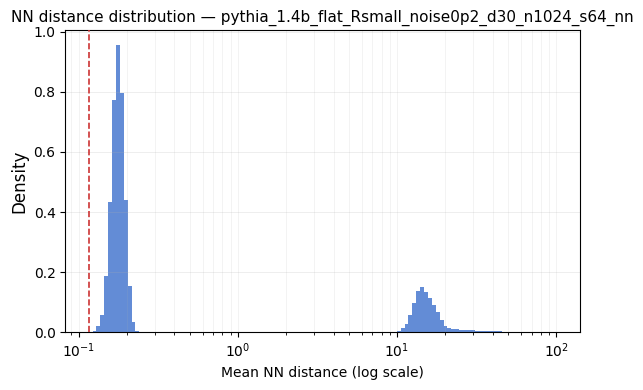

In [6]:
all_dists = df.nn_dist
pos_dists = all_dists[all_dists > 0]
bins = np.geomspace(pos_dists.min(), pos_dists.max(), 121)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pos_dists, bins=bins, density=True, color="#4878CF", alpha=0.85, linewidth=0)
ax.set_xscale("log")
ax.axvline(pos_dists.min(), color="#CC3333", linewidth=1.2, linestyle="--", zorder=3)
ax.set_xlabel("Mean NN distance (log scale)", fontsize=10)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"NN distance distribution — {model_name}", fontsize=11)
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
ax.grid(axis="x", alpha=0.2, linewidth=0.5, which="both")
fig.tight_layout()
plt.show()

## Heatmaps

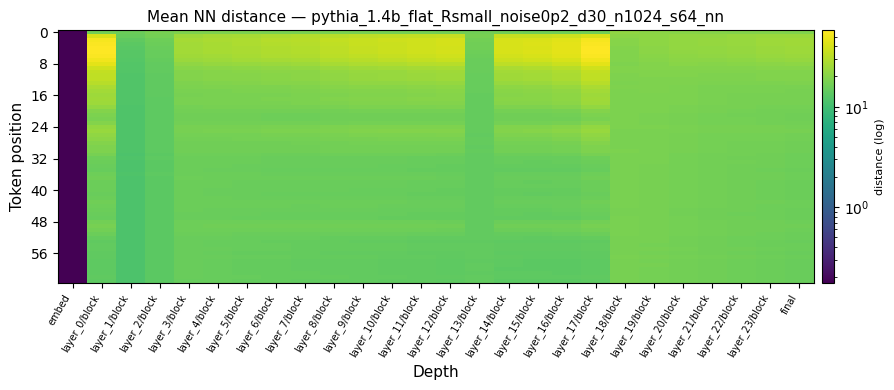

In [11]:
def heatmap(grid, title):
    # Convert grid to numpy array to avoid pandas alignment issues during transposition
    g = np.clip(grid.to_numpy().T, np.finfo(np.float32).tiny, None)
    
    fig, ax = plt.subplots(figsize=(max(8, n_depths * 0.35), 4))
    
    # Handle the edge case where vmin == vmax (which occurs in our 1x1 sample grid)
    # LogNorm raises an error if vmin == vmax
    vmin, vmax = g.min(), g.max()
    if vmin == vmax:
        vmin = vmin * 0.9
        vmax = vmax * 1.1

    im = ax.imshow(g, aspect="auto", origin="upper", interpolation="nearest",
                   cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax))
    cb = fig.colorbar(im, ax=ax, pad=0.01, fraction=0.03)
    cb.ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())
    cb.set_label("distance (log)", fontsize=8)
    
    ax.set_ylabel("Token position", fontsize=11)
    ax.set_title(f"{title} — {model_name}", fontsize=11)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=8))
    ax.set_xticks(range(n_depths))
    ax.set_xticklabels(depths, rotation=60, ha="right", fontsize=7)
    ax.set_xlabel("Depth", fontsize=11)
    
    fig.tight_layout()
    
mean_grid = df.pivot_table(
    index='depth', 
    columns='pos', 
    values='nn_dist', 
    aggfunc='mean'
)
heatmap(mean_grid, "Mean NN distance")